# Baseline Modeling

The goal of this notebook is to build the first leakage-free machine learning models for predicting machine failure.

The dataset is highly imbalanced, so accuracy alone is not sufficient. Evaluation will focus on recall, precision, F1-score, ROC-AUC, and PR-AUC.

Failure-type columns such as TWF, HDF, PWF, OSF, and RNF will not be used as input features because they represent target-level information and would cause data leakage.

In [1]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn import metrics

random_state = 42


In [2]:
df = pd.read_csv('../data/raw/ai4i2020.csv')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.shape

(10000, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [5]:
df['Temp_diff [K]'] = df['Process temperature [K]'] - df['Air temperature [K]']

df['Power [W]'] = (
    df['Torque [Nm]'] *
    df['Rotational speed [rpm]'] *
    2 * np.pi / 60
)

df['Torque_Wear'] = df['Torque [Nm]'] * df['Tool wear [min]']

In [6]:
target_col = 'Machine failure'

id_cols = ['UDI', 'Product ID']

leakage_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

In [7]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Temp_diff [K]', 'Power [W]', 'Torque_Wear'],
      dtype='object')

In [8]:
x = df.drop(columns = [target_col]+id_cols+leakage_cols)
y = df[target_col]
print(x.columns)

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Temp_diff [K]', 'Power [W]', 'Torque_Wear'],
      dtype='object')


### Defining Categorial and Numerical features

In [9]:
categorial_features = ['Type']

numerical_features = [
    col for col in x.columns if col not in categorial_features
]
categorial_features,numerical_features

(['Type'],
 ['Air temperature [K]',
  'Process temperature [K]',
  'Rotational speed [rpm]',
  'Torque [Nm]',
  'Tool wear [min]',
  'Temp_diff [K]',
  'Power [W]',
  'Torque_Wear'])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
print("Train target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Train target distribution:
Machine failure
0    96.6125
1     3.3875
Name: proportion, dtype: float64

Test target distribution:
Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64


A stratified train-test split was used to preserve the failure percentage in both training and testing sets.

### Creating a pipeline

In [12]:
numeric_transformer = Pipeline(steps =[
    ('scaler',StandardScaler())
])
categorial_transformer = Pipeline(steps=[
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

In [13]:
preprocessor = ColumnTransformer(
    transformers =[
        ('num', numeric_transformer,numerical_features),
        ('cat',categorial_transformer,categorial_features)
   ]
)

A preprocessing pipeline ensures that scaling and encoding are fitted only on the training data, preventing data leakage from the test set.

### Creating an Evaluation Function

In [14]:
def evaluate_model(model,X_test,y_test,model_name):
    y_pred=model.predict(X_test)
    if hasattr(model,"predict_proba"):
        y_proba = model.predict_proba(X_test)[:,1]
    else:
        y_proba = None
    
    print(f'====={model_name}=====')
    print(metrics.classification_report(y_test,y_pred))
    
    print("confusion_matrix:")
    cm = metrics.confusion_matrix(y_test,y_pred)
    print(cm)
    
    if y_proba is not None:
        roc_auc = metrics.roc_auc_score(y_test,y_proba)
        pr_auc = metrics.average_precision_score(y_test,y_proba)
        print(f"ROC-AUC: {roc_auc:.4f}")
        print(f"PR-AUC:{pr_auc:.4f}")
    
    disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()
    
    

### Creating a dummy baseline classifier

=====Dummy Classifier=====
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.00      0.00      0.00        68

    accuracy                           0.97      2000
   macro avg       0.48      0.50      0.49      2000
weighted avg       0.93      0.97      0.95      2000

confusion_matrix:
[[1932    0]
 [  68    0]]
ROC-AUC: 0.5000
PR-AUC:0.0340


c:\Users\yhamz\OneDrive\Desktop\Mohamed's work\Predictive Maintainance Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\yhamz\OneDrive\Desktop\Mohamed's work\Predictive Maintainance Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\yhamz\OneDrive\Desktop\Mohamed's work\Predictive Maintainance Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

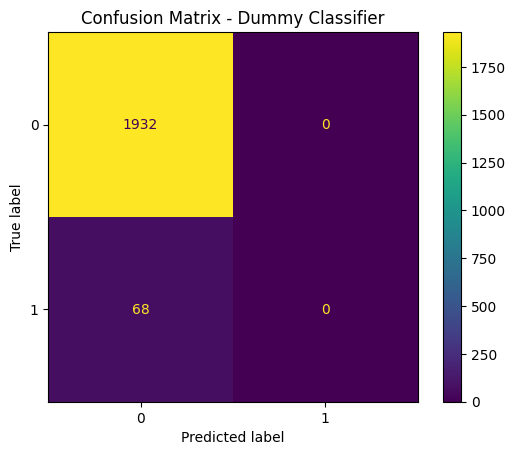

In [15]:
dummy_model = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',DummyClassifier(strategy='most_frequent'))
])
dummy_model.fit(X_train,y_train)

evaluate_model(dummy_model,X_test,y_test,"Dummy Classifier")

The dummy classifier achieves high accuracy by predicting the majority class, but it fails to detect machine failures. This confirms that accuracy is misleading for this imbalanced dataset.

### Training a Logistic Regression Baseline model

=====Logistic Regression=====
              precision    recall  f1-score   support

           0       1.00      0.86      0.92      1932
           1       0.18      0.88      0.30        68

    accuracy                           0.86      2000
   macro avg       0.59      0.87      0.61      2000
weighted avg       0.97      0.86      0.90      2000

confusion_matrix:
[[1657  275]
 [   8   60]]
ROC-AUC: 0.9385
PR-AUC:0.4297


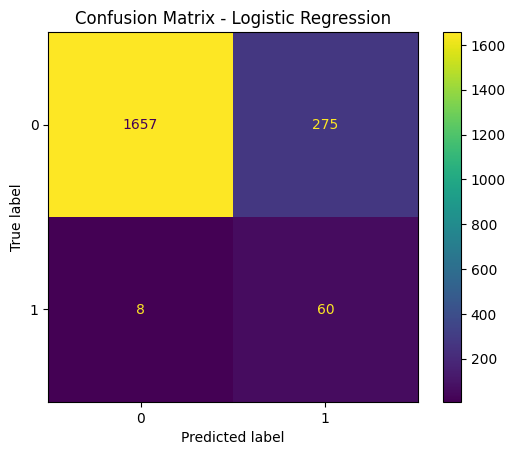

In [16]:
log_reg_model = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state = random_state
    ))
])

log_reg_model.fit(X_train,y_train)

evaluate_model(log_reg_model,X_test,y_test,'Logistic Regression')

Logistic Regression was trained as an interpretable baseline model. Class weights were used to reduce the effect of class imbalance.

### Training Random Forest Baseline Model

=====Random Forest=====
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.96      0.75      0.84        68

    accuracy                           0.99      2000
   macro avg       0.98      0.87      0.92      2000
weighted avg       0.99      0.99      0.99      2000

confusion_matrix:
[[1930    2]
 [  17   51]]
ROC-AUC: 0.9668
PR-AUC:0.8672


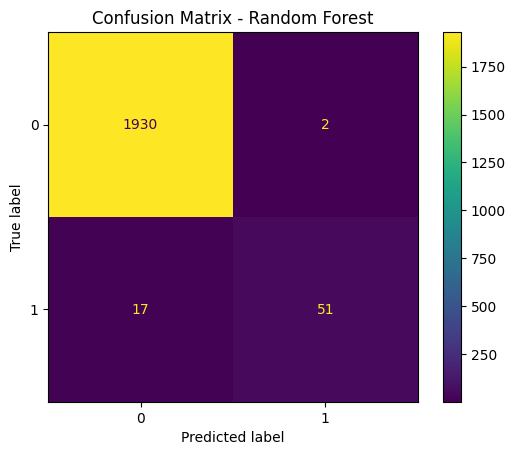

In [17]:
rf_model = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state= random_state,
        n_jobs=-1
    ))
])
rf_model.fit(X_train,y_train)
evaluate_model(rf_model,X_test,y_test,'Random Forest')

Random Forest can capture nonlinear relationships and feature interactions, which are expected in this dataset due to physical relationships such as torque-speed power and torque-wear stress.

### Models Comparison

In [18]:
def get_model_scores(model,X_test,y_test,model_name):
    y_pred = model.predict(X_test)
    
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:,1]
        roc_auc = metrics.roc_auc_score(y_test,y_proba)
        pr_auc = metrics.average_precision_score(y_test,y_proba)
    else:
        roc_auc = np.nan
        pr_auc = np.nan
    
    return {
        'model':model_name,
        'precision' : metrics.precision_score(y_test,y_pred,zero_division=0),
        'recall' : metrics.recall_score(y_test,y_pred,zero_division=0),
        'f1_score' : metrics.f1_score(y_test,y_pred,zero_division=0),
        'ROC_AUC' : roc_auc,
        'PR_AUC' : pr_auc
    }

In [19]:
results = []

results.append(get_model_scores(dummy_model, X_test, y_test, "Dummy Classifier"))
results.append(get_model_scores(log_reg_model, X_test, y_test, "Logistic Regression"))
results.append(get_model_scores(rf_model, X_test, y_test, "Random Forest"))

results_df = pd.DataFrame(results)

results_df

,model,precision,recall,f1_score,ROC_AUC,PR_AUC
0,Dummy Classifier,0.000000,0.000000,0.000000,0.500000,0.034000
1,Logistic Regression,0.179104,0.882353,0.297767,0.938505,0.429703
2,Random Forest,0.962264,0.750000,0.842975,0.966779,0.867192


In [20]:
results_df.sort_values(by='PR_AUC', ascending=False)

,model,precision,recall,f1_score,ROC_AUC,PR_AUC
2,Random Forest,0.962264,0.750000,0.842975,0.966779,0.867192
1,Logistic Regression,0.179104,0.882353,0.297767,0.938505,0.429703
0,Dummy Classifier,0.000000,0.000000,0.000000,0.500000,0.034000


For predictive maintenance, recall is especially important because missing a real failure may lead to downtime, equipment damage, or safety risk. However, precision is also important because too many false alarms can lead to unnecessary maintenance.

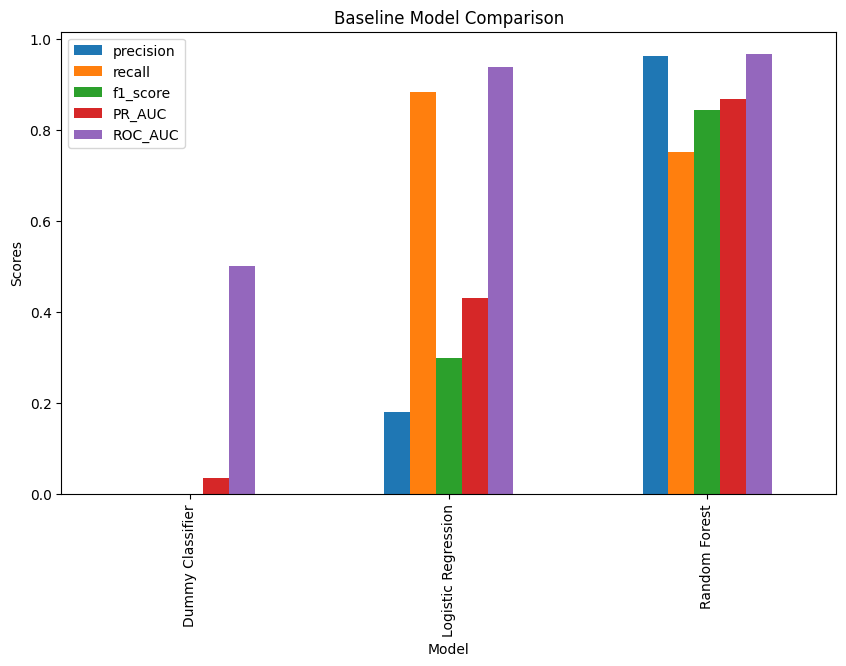

In [22]:
results_df.set_index('model')[['precision', 'recall', 'f1_score', 'PR_AUC', 'ROC_AUC']].plot(
    kind='bar',
    figsize=(10, 6)
)
plt.xlabel("Model")
plt.ylabel("Scores")
plt.title("Baseline Model Comparison")
plt.show()

### Feature Importance analysis

In [31]:
preprocessor_fitted = rf_model.named_steps['preprocessor']
encoded_cat_features = preprocessor_fitted.named_transformers_['cat'] \
    .named_steps['onehot'] \
    .get_feature_names_out(categorial_features)
encoded_cat_features

array(['Type_H', 'Type_L', 'Type_M'], dtype=object)

In [48]:
all_feature_names = np.concatenate([
    numerical_features,
    encoded_cat_features
])
rf_classifier = rf_model.named_steps['classifier']
feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': rf_classifier.feature_importances_
}).sort_values(by='Importance',ascending=False)
feature_importance

,Feature,Importance
2,Rotational speed [rpm],0.215772
3,Torque [Nm],0.183230
6,Power [W],0.177505
4,Tool wear [min],0.134607
7,Torque_Wear,0.112012
5,Temp_diff [K],0.084747
0,Air temperature [K],0.050544
1,Process temperature [K],0.030519
10,Type_M,0.004595
9,Type_L,0.004009


Random Forest feature importance provides an initial view of influential variables, but it should not be treated as final explanation. More robust explainability such as permutation importance or SHAP will be used later.

In [50]:
results_df.to_csv('../reports/baseline_models_results.csv', index = False)

# Baseline models summary

A leakage-free baseline modeling pipeline was created.

Main actions completed:
1. Loaded the dataset from scratch.
2. Recreated domain-inspired engineered features:
   - Temperature difference
   - Mechanical power
   - Torque-wear interaction
3. Removed identifier columns and failure-type leakage columns.
4. Split the data using stratified train-test split.
5. Built a preprocessing pipeline for numerical and categorical features.
6. Trained three baseline models:
   - Dummy Classifier
   - Logistic Regression
   - Random Forest
7. Evaluated models using precision, recall, F1-score, ROC-AUC, and PR-AUC.

Main findings:
- Accuracy is not reliable because the dataset is highly imbalanced.
- The dummy classifier performs poorly at detecting failures.
- Logistic Regression provides an interpretable baseline.
- Random Forest is expected to perform better because it can capture nonlinear interactions.
- Future work should focus on threshold tuning, cross-validation, imbalance handling, hyperparameter tuning, and explainability.